In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings("ignore")

## Import Dataset

In [46]:
df = pd.read_csv("data.csv")
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28,0,> 2 Years,Yes,40454,26,217,1
1,2,Male,76,1,3,0,1-2 Year,No,33536,26,183,0
2,3,Male,47,1,28,0,> 2 Years,Yes,38294,26,27,1
3,4,Male,21,1,11,1,< 1 Year,No,28619,152,203,0
4,5,Female,29,1,41,1,< 1 Year,No,27496,152,39,0


* id: Unique ID for the customer
* Gender: Gender of the customer
* Age: Age of the customer
* Driving_License: [0 : Customer does not have DL, 1 : Customer already has DL]
* Region_Code: Unique code for the region of the customer
* Previously_Insured: [1 : Customer already has Vehicle Insurance, 0 : Customer doesn't have Vehicle Insurance]
* Vehicle_Age: Age of the Vehicle
* Vehicle_Damage: [1 : Customer got his/her vehicle damaged in the past. 0 : Customer didn't get his/her vehicle damaged in the past.]
* Annual_Premium: The amount customer needs to pay as premium in the year
* Policy_Sales_Channel: Anonymized Code for the channel of outreaching to the customer ie. Different Agents, Over Mail, Over Phone, In Person, etc.
* Vintage: Number of Days, Customer has been associated with the company
* Response: [1 : Customer is interested, 0 : Customer is not interested]

## EDA

In [47]:
df.shape

(41780, 12)

In [48]:
# checking for null values
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41780 entries, 0 to 41779
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    41780 non-null  int64 
 1   Gender                41780 non-null  object
 2   Age                   41780 non-null  int64 
 3   Driving_License       41780 non-null  int64 
 4   Region_Code           41780 non-null  int64 
 5   Previously_Insured    41780 non-null  int64 
 6   Vehicle_Age           41780 non-null  object
 7   Vehicle_Damage        41780 non-null  object
 8   Annual_Premium        41780 non-null  int64 
 9   Policy_Sales_Channel  41780 non-null  int64 
 10  Vintage               41780 non-null  int64 
 11  Response              41780 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 3.8+ MB


In [50]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,41780.00000,41780.000000,41780.000000,41780.000000,41780.000000,41780.000000,41780.000000,41780.000000,41780.000000
mean,20890.50000,38.794040,0.997822,26.451484,0.458066,30540.575921,112.488128,154.169986,0.121805
std,12060.99146,15.545335,0.046620,13.177307,0.498244,17033.474743,53.961810,83.546267,0.327064
min,1.00000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,10445.75000,25.000000,1.000000,15.000000,0.000000,24372.000000,30.000000,82.000000,0.000000
50%,20890.50000,36.000000,1.000000,28.000000,0.000000,31733.000000,150.000000,154.000000,0.000000
75%,31335.25000,49.000000,1.000000,35.000000,1.000000,39516.250000,152.000000,227.000000,0.000000
max,41780.00000,84.000000,1.000000,52.000000,1.000000,508073.000000,163.000000,299.000000,1.000000


In [51]:
# checking distribution for target column
df['Response'].value_counts()

Response
0    36691
1     5089
Name: count, dtype: int64

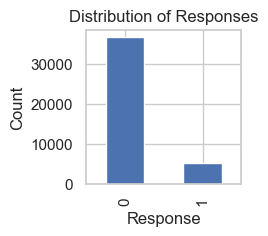

In [52]:
value_counts = df['Response'].value_counts()

plt.figure(figsize=(2, 2))

# Create the bar plot
value_counts.plot(kind='bar')

# Customize the plot (optional)
plt.xlabel('Response')
plt.ylabel('Count')
plt.title('Distribution of Responses')

# Show the plot
plt.show()

<Axes: >

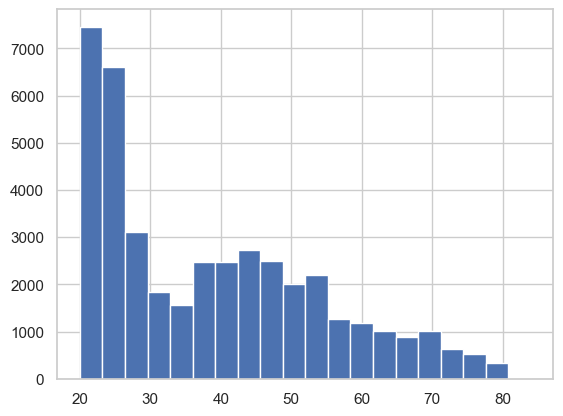

In [53]:
# checking distribution for age col
df['Age'].hist(bins=20)

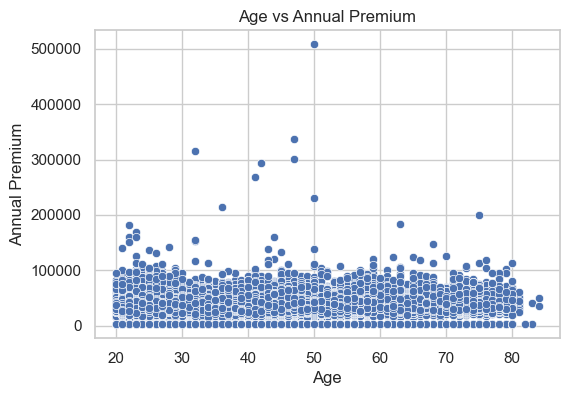

In [54]:
# Scatter Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Age', y='Annual_Premium', data=df)
plt.title('Age vs Annual Premium')
plt.xlabel('Age')
plt.ylabel('Annual Premium')
plt.show()

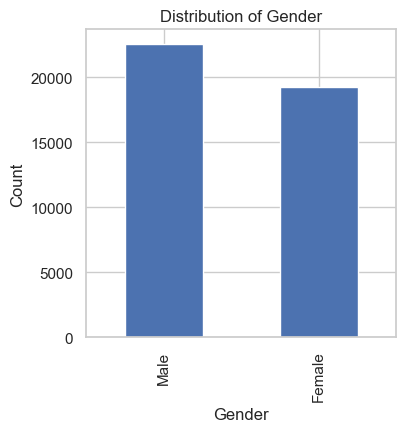

In [55]:
# Gender-Response comparison

value_counts = df['Gender'].value_counts()
plt.figure(figsize=(4, 4))

# Create the bar plot
value_counts.plot(kind='bar')

# Customize the plot (optional)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')

# Show the plot
plt.show()

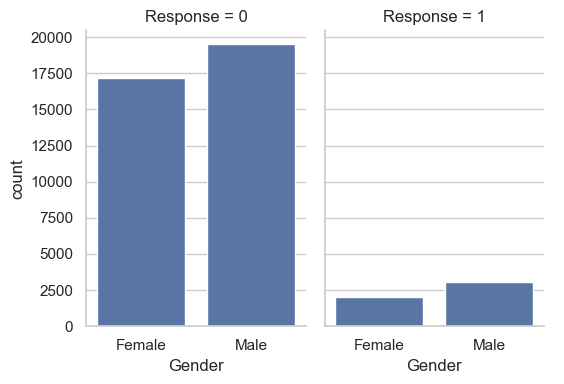

In [56]:
data = df.groupby(['Gender','Response'])['id'].count().to_frame().rename(columns={'id':'count'}).reset_index()

g = sns.catplot(x="Gender", y="count",col="Response", data=data, kind="bar", height=4, aspect=.7);

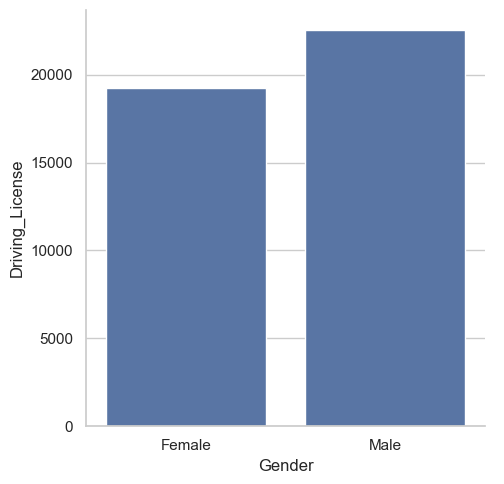

In [57]:
# driving license by gender

data=df.groupby(['Gender'])['Driving_License'].count().to_frame().reset_index()
sns.catplot(x="Gender", y="Driving_License", data=data, kind="bar");

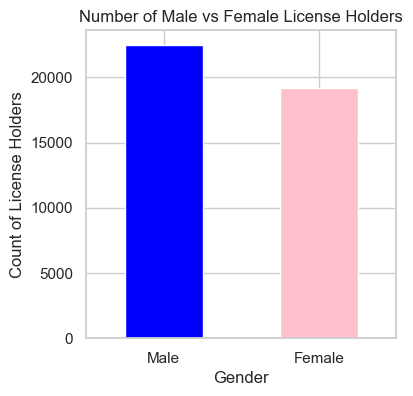

In [58]:
# Filter for only license holders (Driving_License == 1)
license_holders = df[df['Driving_License'] == 1]

# Group by Gender and count the number of license holders per gender
gender_counts = license_holders['Gender'].value_counts()

# Plotting
plt.figure(figsize=(4, 4))
gender_counts.plot(kind='bar', color=['blue', 'pink'])
plt.title('Number of Male vs Female License Holders')
plt.xlabel('Gender')
plt.ylabel('Count of License Holders')
plt.xticks(rotation=0)
plt.show()


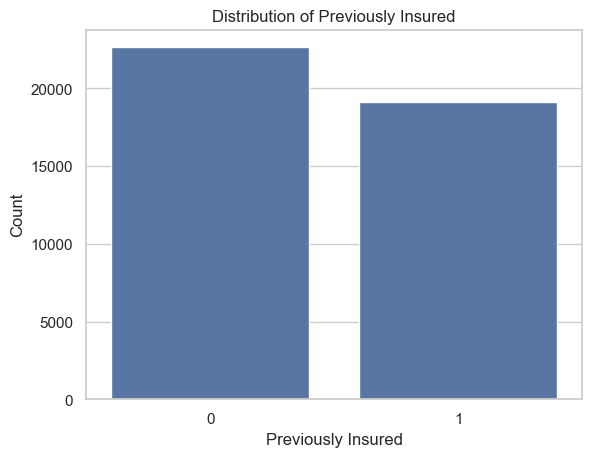

In [59]:
# customers with existing insurance

sns.countplot(x="Previously_Insured", data=df)
plt.title("Distribution of Previously Insured")
plt.xlabel("Previously Insured")
plt.ylabel("Count")
plt.show()

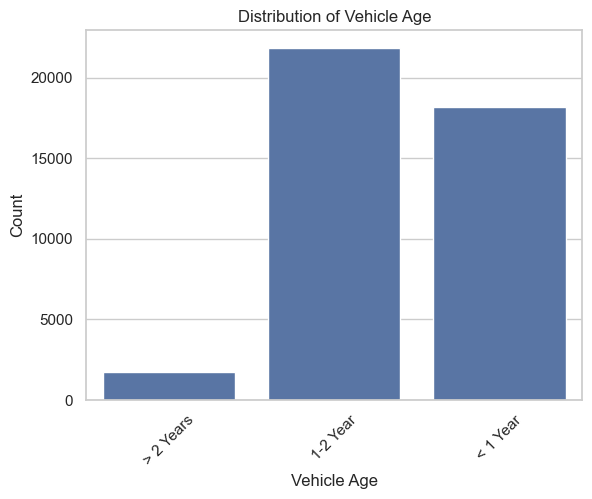

In [60]:
# checking vehicle age dist

sns.countplot(x='Vehicle_Age', data=df)
plt.xlabel('Vehicle Age')
plt.ylabel('Count')
plt.title('Distribution of Vehicle Age')
plt.xticks(rotation=45)  # Rotate x-axis labels if they overlap
plt.show()

In [61]:
# Response vs Vehicle_Age

data=df.groupby(['Vehicle_Age','Response'])['id'].count().to_frame().rename(columns={'id':'count'}).reset_index()
data

,Vehicle_Age,Response,count
0,1-2 Year,0,18051
1,1-2 Year,1,3806
2,< 1 Year,0,17404
3,< 1 Year,1,775
4,> 2 Years,0,1236
5,> 2 Years,1,508


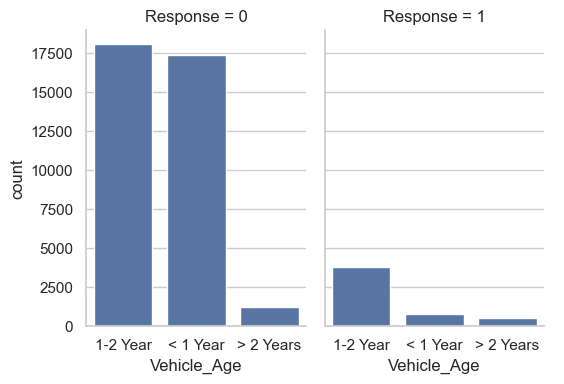

In [62]:
g = sns.catplot(x="Vehicle_Age", y="count",col="Response",
                data=data, kind="bar",
                height=4, aspect=.7);

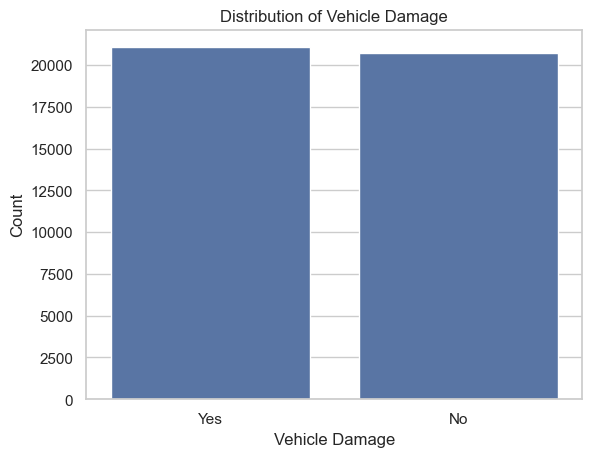

In [63]:
# dist for Vehicle_Damage col

sns.countplot(data=df, x='Vehicle_Damage')
plt.title('Distribution of Vehicle Damage')
plt.xlabel('Vehicle Damage')
plt.ylabel('Count')
plt.show()

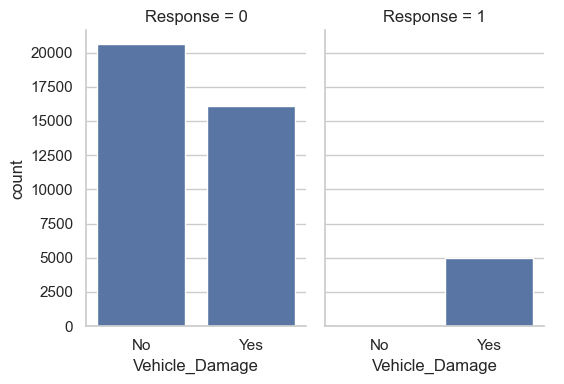

In [64]:
data = df.groupby(['Vehicle_Damage','Response'])['id'].count().to_frame().rename(columns={'id':'count'}).reset_index()
g = sns.catplot(x="Vehicle_Damage", y="count",col="Response", data=data, kind="bar", height=4, aspect=.7);

In [65]:
# checking stats for Annual_Premium
df['Annual_Premium'].describe()

count     41780.000000
mean      30540.575921
std       17033.474743
min        2630.000000
25%       24372.000000
50%       31733.000000
75%       39516.250000
max      508073.000000
Name: Annual_Premium, dtype: float64

<Axes: >

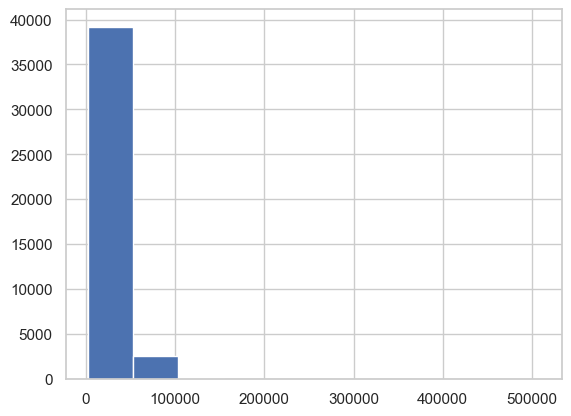

In [66]:
df['Annual_Premium'].hist(bins=10)

In [67]:
df[df['Annual_Premium']>200000]

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
1412,1413,Female,41,1,28,0,1-2 Year,Yes,267698,124,63,1
11319,11320,Female,50,1,46,1,1-2 Year,No,508073,26,192,0
13426,13427,Female,47,1,28,0,1-2 Year,Yes,301762,124,22,0
15024,15025,Female,32,1,28,0,1-2 Year,Yes,315565,155,150,0
25532,25533,Male,50,1,28,0,1-2 Year,Yes,229935,122,64,1
35280,35281,Female,42,1,28,1,1-2 Year,No,294209,26,238,0
37855,37856,Male,47,1,28,0,1-2 Year,Yes,336395,122,69,1
39479,39480,Female,36,1,28,0,1-2 Year,Yes,214455,26,249,0


## Data Preprocessing

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41780 entries, 0 to 41779
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    41780 non-null  int64 
 1   Gender                41780 non-null  object
 2   Age                   41780 non-null  int64 
 3   Driving_License       41780 non-null  int64 
 4   Region_Code           41780 non-null  int64 
 5   Previously_Insured    41780 non-null  int64 
 6   Vehicle_Age           41780 non-null  object
 7   Vehicle_Damage        41780 non-null  object
 8   Annual_Premium        41780 non-null  int64 
 9   Policy_Sales_Channel  41780 non-null  int64 
 10  Vintage               41780 non-null  int64 
 11  Response              41780 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 3.8+ MB


In [69]:
num_feat = ['Age','Vintage']
cat_feat = ['Gender', 'Driving_License', 'Previously_Insured', 'Vehicle_Age_lt_1_Year',
'Vehicle_Age_gt_2_Years','Vehicle_Damage_Yes','Region_Code','Policy_Sales_Channel']

In [70]:
# mapping 'Gender' col to (0, 1) values
df['Gender'] = df['Gender'].map( {'Female': 0, 'Male': 1} ).astype(int)
df.head(2)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,1,44,1,28,0,> 2 Years,Yes,40454,26,217,1
1,2,1,76,1,3,0,1-2 Year,No,33536,26,183,0


In [71]:
for col in df.columns:
    print(f"{col} >> {df[col].dtype}")

id >> int64
Gender >> int64
Age >> int64
Driving_License >> int64
Region_Code >> int64
Previously_Insured >> int64
Vehicle_Age >> object
Vehicle_Damage >> object
Annual_Premium >> int64
Policy_Sales_Channel >> int64
Vintage >> int64
Response >> int64


In [72]:
# creating dummy cols for categorical features

df=pd.get_dummies(df,drop_first=True)
df.head(2)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,1,1,44,1,28,0,40454,26,217,1,False,True,True
1,2,1,76,1,3,0,33536,26,183,0,False,False,False


In [73]:
for col in df.columns:
    print(f"{col} >> {df[col].dtype}")

id >> int64
Gender >> int64
Age >> int64
Driving_License >> int64
Region_Code >> int64
Previously_Insured >> int64
Annual_Premium >> int64
Policy_Sales_Channel >> int64
Vintage >> int64
Response >> int64
Vehicle_Age_< 1 Year >> bool
Vehicle_Age_> 2 Years >> bool
Vehicle_Damage_Yes >> bool


In [74]:
# cols renaming and keeping dtype as int

df = df.rename(columns={"Vehicle_Age_< 1 Year": "Vehicle_Age_lt_1_Year", "Vehicle_Age_> 2 Years": "Vehicle_Age_gt_2_Years"})
df['Vehicle_Age_lt_1_Year'] = df['Vehicle_Age_lt_1_Year'].astype('int')
df['Vehicle_Age_gt_2_Years'] = df['Vehicle_Age_gt_2_Years'].astype('int')
df['Vehicle_Damage_Yes'] = df['Vehicle_Damage_Yes'].astype('int')

for column in cat_feat:
    df[column] = df[column].astype('str')

In [75]:
# scaling the data

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler

ss = StandardScaler()
df[num_feat] = ss.fit_transform(df[num_feat])


mm = MinMaxScaler()
df[['Annual_Premium']] = mm.fit_transform(df[['Annual_Premium']])

# also, dropping id col now
id=df.id
df=df.drop('id',axis=1)

In [76]:
# train-test split

from sklearn.model_selection import train_test_split

train_target=df['Response']
train=df.drop(['Response'], axis = 1)
x_train,x_test,y_train,y_test = train_test_split(train,train_target, random_state = 0)

In [77]:
train_target

0        1
1        0
2        1
3        0
4        0
        ..
41775    0
41776    0
41777    1
41778    0
41779    0
Name: Response, Length: 41780, dtype: int64

In [78]:
train.head(1)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Vehicle_Age_lt_1_Year,Vehicle_Age_gt_2_Years,Vehicle_Damage_Yes
0,1,0.334893,1,28,0,0.074833,26,0.752048,0,1,1


## Model Trainer - Random Forest Classifier

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

random_search = {'criterion': ['entropy', 'gini'],
               'max_depth': [2,3,4,5,6,7,10],
               'min_samples_leaf': [4, 6, 8],
               'min_samples_split': [5, 7,10],
               'n_estimators': [300]}

clf = RandomForestClassifier()
model = RandomizedSearchCV(estimator = clf, param_distributions = random_search, n_iter = 10, 
                               cv = 4, verbose= 1, random_state= 101, n_jobs = -1)
model.fit(x_train,y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'criterion': ['entropy', 'gini'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [4, 6, ...], 'min_samples_split': [5, 7, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,101
,error_score,nan


In [80]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define hyperparameter search space
param_dist = {
    'n_estimators': randint(100, 500),       # Random integers between 100 and 500
    'max_depth': randint(5, 20),             # Random integers between 5 and 20
    'min_samples_split': randint(2, 15),     # Random integers between 2 and 15
    'min_samples_leaf': randint(1, 10),      # Random integers between 1 and 10
    'criterion': ['gini', 'entropy', 'log_loss']  # Categorical choice
}

clf = RandomForestClassifier(random_state=101)

# Randomized search with cross-validation
model = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=20,           # number of random combinations to try
    cv=4,                # 4-fold CV
    verbose=2,
    random_state=101,
    n_jobs=-1
)

# Fit on training data
model.fit(x_train, y_train)

# Best parameters and score
print("Best Parameters:", model.best_params_)
print("Best CV Score:", model.best_score_)


Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 11, 'min_samples_leaf': 8, 'min_samples_split': 13, 'n_estimators': 493}
Best CV Score: 0.8793362061708057


In [81]:
best_params = model.best_params_

print("Best Hyperparameters:")
print(best_params)

Best Hyperparameters:
{'criterion': 'entropy', 'max_depth': 11, 'min_samples_leaf': 8, 'min_samples_split': 13, 'n_estimators': 493}


In [82]:
# save model

import pickle

filename = 'rf_model.pkl'
pickle.dump(model, open(filename, 'wb'))

In [83]:
# loading back pickle file

rf_load = pickle.load(open(filename, 'rb'))

## Model Evaluation

In [84]:
from sklearn.metrics import classification_report

y_pred=model.predict(x_test)
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93      9137
           1       0.00      0.00      0.00      1308

    accuracy                           0.87     10445
   macro avg       0.44      0.50      0.47     10445
weighted avg       0.77      0.87      0.82     10445

